## Model Training On Real Data

In [2]:
# import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load Dataset

In [3]:
transactions_data = pd.read_csv("data/credit_card_data_real.zip", compression="zip")
print(transactions_data.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

## Class Imbalance

As it can be seen here there is a class imbalance poblem with the dataset. The fraudulent transactions are only 492 or less than 1% of the entire dataset

In [6]:
print(transactions_data["Class"].value_counts())
print()
print(transactions_data["Class"].value_counts(normalize=True))

Class
0    284315
1       492
Name: count, dtype: int64

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


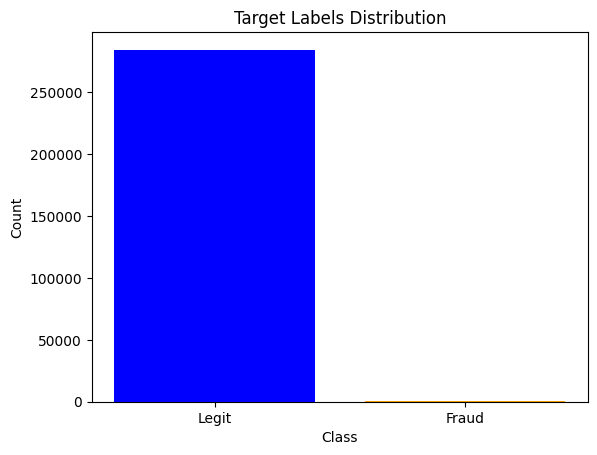

In [8]:
plt.bar(transactions_data["Class"].value_counts().index, transactions_data["Class"].value_counts().values, color=["blue", "orange"])
plt.xticks([0, 1], ["Legit", "Fraud"])
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Target Labels Distribution")
plt.show()

## Data Preparation

### Data Resampling

As seen before the data has to be resampled to mitigate the class imbalance problem. SMOTE is uased again to over-sample the minority class

In [10]:
from imblearn.over_sampling import SMOTE

X = transactions_data.drop(["Class"], axis=1)
y = transactions_data["Class"]

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)